In [1]:
# 텐서플로 라이브러리 안에 있는 케라스 API에서 필요한 함수들을 불러옵니다.
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense   

# 데이터를 다루는 데 필요한 라이브러리를 불러옵니다.
import numpy as np
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense, Input

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [3]:
from sklearn.model_selection import train_test_split
# ==========================
# 2. 학습/테스트 분리
# ==========================

x_train,x_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y # 같은 비율로 들어 갈수 있도록 #분류 모델에서는 stratify=y 로 할것 
)

In [4]:
from sklearn.preprocessing import StandardScaler

# ==========================
# 3. 정규화
# ==========================
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [5]:
# ==========================
# 4. 모델 생성
# ==========================
model = Sequential([
    Input(shape=(4,)),  # 컬럼 4
    Dense(8,activation="relu"),
    Dense(4,activation="relu"),
    Dense(3,activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ==========================
# 5. 컴파일
# ==========================
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# ==========================
# 6. 학습
# ==========================
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.1979 - loss: 1.0849 - val_accuracy: 0.3750 - val_loss: 1.0700
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2812 - loss: 1.0671 - val_accuracy: 0.4167 - val_loss: 1.0531
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2917 - loss: 1.0511 - val_accuracy: 0.4167 - val_loss: 1.0371
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3333 - loss: 1.0338 - val_accuracy: 0.4583 - val_loss: 1.0220
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3854 - loss: 1.0185 - val_accuracy: 0.5000 - val_loss: 1.0075
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4479 - loss: 1.0033 - val_accuracy: 0.4583 - val_loss: 0.9944
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5208 - loss: 0.9895 - val_accuracy: 0.5000 - val_loss: 0.9830
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5938 - loss: 0.9763 - val_accuracy: 0.5417 - val_loss

In [8]:
# ==========================
# 7. 평가
# ==========================
loss, acc = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.7667 - loss: 0.4604


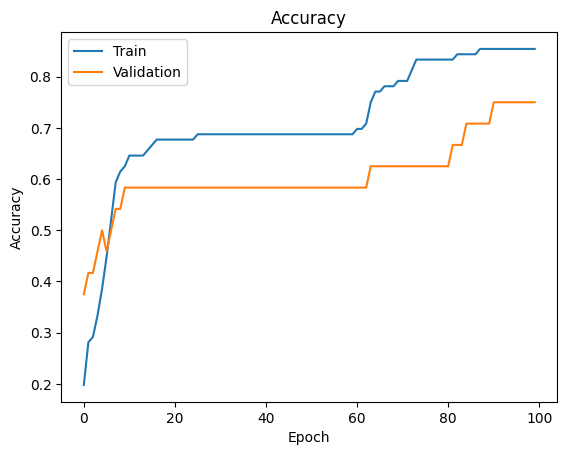

In [9]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

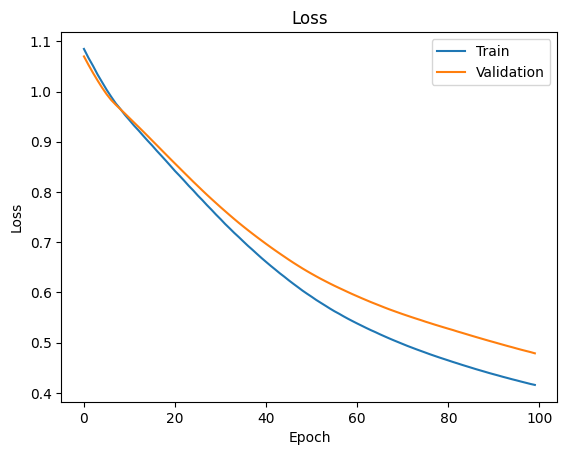

In [10]:
# ==========================
# 9. Loss 그래프
# ==========================

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [11]:
# ==========================
# 10. 새로운 꽃 예측
# ==========================
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
new_flower = scaler.transform(new_flower)

pred = model.predict(new_flower)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


array([[0.98299897, 0.00979507, 0.00720607]], dtype=float32)